## 97. Validation Insitu
0. Packages
1. Settings
2. Read Data
3. Plot data

### 0. Packages

In [1]:
# Packages
import colormaps as cmaps
import glob
import geopandas as gpd
import colormaps as cmaps
import numpy as np
import os
import rioxarray as rxr
from rioxarray.merge import merge_arrays
import xarray as xr
from shapely.geometry import box

from resilientplotterclass import rpclass

### 1. Settings

In [2]:
# File paths gtsm
file_path_gtsm_combined_zarr = r'p:\1230882-emodnet_hrsm\GTSMv3.0EMODnet\CMEMS_intertidal_SDB\zarr_files\gtsm_model_his_combined_v2.zarr'
file_path_gtsm_stations_parquet = r'p:\11209821-cmems-global-sdb\01_intertidal\02_data\02_gtsm_files\gtsm_stations_v2.parquet'

# File paths gebco
file_path_gebco_tif = r'p:\11209821-cmems-global-sdb\01_intertidal\02_data\03_gebco_files\gebco_2024.tif'
file_path_gebco_hat_lat_tif = r'p:\11209821-cmems-global-sdb\01_intertidal\02_data\03_gebco_files\gebco_2024_hat_lat.tif'

# URLs to global lat/hat data (LAT/HAT wrt MSL based on gebco 2023)
file_path_global_lat_zarr = r'https://nx7384.your-storageshare.de/apps/sharingpath/wetwin/public/gebco2023/lat.zarr'
file_path_global_hat_zarr = r'https://nx7384.your-storageshare.de/apps/sharingpath/wetwin/public/gebco2023/hat.zarr'

# File paths feasibility map
file_path_fm_parquet = r'p:\11209821-cmems-global-sdb\00_miscellaneous\Feasibility_maps\2024\gebco_2024_latminus2_merge_result.parquet'
file_path_fm_ed_parquet = r'p:\11209821-cmems-global-sdb\00_miscellaneous\Feasibility_maps\2024\gebco_2024_latminus2_merge_result_erosion_dilation.parquet'

# File paths tiles
file_path_tiles_parquet = r'p:\11209821-cmems-global-sdb\00_miscellaneous\AOI_polygons_world\df_boxes_world_Z10_filtered_v2.parquet'

# File paths osm
file_path_osm_tifs = glob.glob(r'p:\11209821-cmems-global-sdb\01_intertidal\02_data\00_osm_files\water_rasters\*.tif')
file_path_osm_parquet = r'p:\11209821-cmems-global-sdb\01_intertidal\02_data\00_osm_files\geometries\osm_water_metadata.parquet'

# File paths sdbs
file_path_sdbs = glob.glob(r'p:\11209821-cmems-global-sdb\01_intertidal\02_data\05_calibrated\intertidal_improved_100m_global\05_reprojected\*.tif')
file_path_sdbs = [file_path for file_path in file_path_sdbs if not file_path.endswith('.tif.aux.xml')]
file_path_sdbs = {os.path.basename(file_path).split('_t')[0]: file_path for file_path in file_path_sdbs}

# File paths insitus
file_path_insitus = [
    r'p:\11209821-cmems-global-sdb\01_intertidal\02_data\06_validation\Local\NL2018_v2.tif',
    r'p:\11209821-cmems-global-sdb\00_miscellaneous\Validation_data\GER_WaddenSea_BSHGeopoartal_WGS84_100m_LAT.tif',
    r'p:\11209821-cmems-global-sdb\01_intertidal\02_data\06_validation\Local\MNT_ATL100m_HOMONIM_GEO_refNM_ZNEG.tif',
]

In [3]:
# Define guidelines
gls = {
    'general':
        {'crs': 'EPSG:4326',
         'cartopy_bounds': [3.5, 7, 51, 54],
         'cartopy_features': ['land', 'ocean', 'lakes', 'coastline', 'borders']},
    'geom_style':
        {'gtsm': {'color': 'blue', 'markersize': 10, 'label': 'GTSM stations'},
         'tiles': {'facecolor': 'none', 'edgecolor': 'black', 'linewidth': 1.5, 'label': 'Tiles'},
         'feasibility_map': {'facecolor': 'blue', 'edgecolor': 'None', 'alpha': 0.25, 'linewidth': 1.5, 'label': 'Feasibility map'},
         'feasibility_map_ed': {'facecolor': 'red', 'edgecolor': 'None', 'alpha': 0.25, 'linewidth': 1.5, 'label': 'Feasibility map (erosion-dilation)'},
         'tiles nearest distance': {'column': 'nearest_station_distance', 'vmin': 0, 'vmax': 50, 'cmap': 'Greens_r', 'alpha': 0.5, 'legend': True, 'legend_kwds': {'label': 'Distance to nearest GTSM station [km]'}, 'append_axes_kwargs': {'position': 'right', 'size': 0.2, 'pad': 0.2}},
         'tiles intertidal coverage': {'column': 'intertidal_coverage', 'vmin': 0, 'vmax': 100, 'cmap': 'Greens', 'alpha': 0.5, 'legend': True, 'legend_kwds': {'label': 'Intertidal coverage [%]'}, 'append_axes_kwargs': {'position': 'right', 'size': 0.2, 'pad': 0.2}},
         'tiles filtered': {'facecolor': 'none', 'edgecolor': 'red', 'linewidth': 1.5, 'label': 'Filtered tiles'}},
    'extent_style':
        {'dutch waddenzee': {'xlim': [5.625000001956855, 6.328125001956671], 'ylim': [53.33087298454682, 53.540307393022395]}, #{'xlim': [5.2734375019479645, 5.976562501956762], 'ylim': [53.12040528463854, 53.540307393022395]},
         'german waddenzee': {'xlim': [7.0312500019654705, 7.73437500197427], 'ylim': [53.540307393022395, 53.956085532500275]}, #{'xlim': [8.085937501974177, 8.789062501982977], 'ylim': [53.540307393022395, 53.956085532500275]}, #
         'thames estuary': {'xlim': [0.3515625018953532, 1.0546875019041522], 'ylim': [51.39920565513004, 51.83577752201909]},
         'le mont-saint-michel': {'xlim': [-2.1093749981309524, -1.4062499981221528], 'ylim': [48.458351884449186, 48.9224992653895]},
         'pertuis d antioche': {'xlim': [-1.757812498122061, -1.054687498122245], 'ylim': [45.82879925362075, 46.31658418351273]},
            
         #'waddenzee': {'xlim': [4.5703125 - 0.02, 5.625 + 0.02], 'ylim': [52.90890205 - 0.02, 53.54030739 + 0.02]},
         #'le mont-saint-michel': {'xlim': [-2.109375 - 0.02, -1.40625 + 0.02], 'ylim': [48.45835188 - 0.02, 48.92249927 + 0.02]},
         
         
         
         #'bristol channel': {'xlim': [-3.515625 - 0.02, -2.4609375 + 0.02], 'ylim': [51.17934298 - 0.02, 51.61801655 + 0.02]},
         #'corner inlet': {'xlim': [145.8984375 - 0.02, 146.6015625 + 0.02], 'ylim': [-39.09596294 - 0.02, -38.54816542 + 0.02]},
         #'karumba': {'xlim': [140.2734375 - 0.02, 140.9765625 + 0.02], 'ylim': [-17.64402203 - 0.02, -17.30868789 + 0.02]},
         #'shark Bay': {'xlim': [113.5546875 - 0.02, 114.2578125 + 0.02], 'ylim': [-26.11598592 - 0.02, -25.48295117 + 0.02]},
         #'giralia': {'xlim': [113.90625 - 0.02, 114.609375 + 0.02], 'ylim': [-22.59372606 - 0.02, -21.94304553 + 0.02]},
         #'brisbane': {'xlim': [152.9296875 - 0.02, 153.6328125 + 0.02], 'ylim': [-27.68352808 - 0.02, -27.05912578 + 0.02]},
         #'karumba': {'xlim': [139.921875 - 0.02, 140.625 + 0.02], 'ylim': [-17.97873309 - 0.02, -17.30868789 + 0.02]},
         #'netherlands': {'xlim': [3.5, 7], 'ylim': [51, 54]},
         'europe': {'xlim': [4, 9], 'ylim': [52, 55]},
         #'global': {'xlim': [-180, 180], 'ylim': [-90, 90]},
         }
    }

# Set guidelines
rpc = rpclass(gls)

# Get guidelines
gls = rpc.get_guidelines()

# Get bounds and crs
crs = gls['general']['crs']
bounds = gls['general']['cartopy_bounds']

# Show guidelines
rpc.show_guidelines(open=False)

### 2. Read Data

In [4]:
# Read gtsm
ds_gtsm_combined = xr.open_zarr(file_path_gtsm_combined_zarr, consolidated=True)
gdf_gtsm_stations = gpd.read_parquet(file_path_gtsm_stations_parquet)

# Read gebco
ds_gebco = rxr.open_rasterio(file_path_gebco_tif, masked=True).squeeze()
ds_gebco_hat_lat = rxr.open_rasterio(file_path_gebco_hat_lat_tif, masked=True)

# Read global hat and lat data
da_global_hat = xr.open_zarr(file_path_global_hat_zarr)['hat_correction']
da_global_hat = da_global_hat.rename({'lat':'y', 'lon':'x'})
da_global_hat = da_global_hat.rio.write_crs('EPSG:4326')
da_global_lat = xr.open_zarr(file_path_global_lat_zarr)['lat_correction']
da_global_lat = da_global_lat.rename({'lat':'y', 'lon':'x'})
da_global_lat = da_global_lat.rio.write_crs('EPSG:4326')

# Combine along band dimension
da_global_hat_lat = xr.merge([da_global_hat, da_global_lat], compat='override').to_dataarray(dim='band')
ds_gebco_hat_lat = da_global_hat_lat

# Read feasibility map
gdf_fm = gpd.read_parquet(file_path_fm_parquet)
gdf_fm_ed = gpd.read_parquet(file_path_fm_ed_parquet)

# Read tiles
gdf_tiles = gpd.read_parquet(file_path_tiles_parquet)
gdf_tiles['nearest_station_distance'] = gdf_tiles['nearest_station_distance']/1000  # Convert to km
gdf_tiles['intertidal_coverage'] = gdf_tiles['intertidal_coverage']*100  # Convert to percentage
gdf_tiles['intertidal_coverage_ed'] = gdf_tiles['intertidal_coverage_ed']*100  # Convert to percentage
gdf_tiles['processed'] = (gdf_tiles['nearest_station_distance'] < 37) & (gdf_tiles['intertidal_coverage'] > 0) & (gdf_tiles['intertidal_coverage_ed'] > 1)
print('Number of tiles:', len(gdf_tiles))
print(gdf_tiles['processed'].value_counts())

# Add file path sdb to gdf_tiles
gdf_tiles['file_path_sdb'] = gdf_tiles['name'].apply(
    lambda x: file_path_sdbs.get(x, None)
)

# Read osm
gdf_osm = gpd.read_parquet(file_path_osm_parquet)

# Read insitus
ds_insitus = [rxr.open_rasterio(file_path, masked=True).squeeze() for file_path in file_path_insitus]
gdf_insitus = gpd.GeoDataFrame(data={'file_path': file_path_insitus, 'geometry': [box(*ds.rio.bounds()) for ds in ds_insitus]}, crs=crs)
del ds_insitus

Number of tiles: 38639
processed
False    27307
True     11332
Name: count, dtype: int64


In [5]:
file_path_sdbs

{'z10_x261_y459': 'p:\\11209821-cmems-global-sdb\\01_intertidal\\02_data\\05_calibrated\\intertidal_improved_100m_global\\05_reprojected\\z10_x261_y459_t2021-01-01_2022-01-01.tif',
 'z10_x572_y284': 'p:\\11209821-cmems-global-sdb\\01_intertidal\\02_data\\05_calibrated\\intertidal_improved_100m_global\\05_reprojected\\z10_x572_y284_t2021-01-01_2022-01-01.tif',
 'z10_x657_y242': 'p:\\11209821-cmems-global-sdb\\01_intertidal\\02_data\\05_calibrated\\intertidal_improved_100m_global\\05_reprojected\\z10_x657_y242_t2021-01-01_2022-01-01.tif',
 'z10_x226_y194': 'p:\\11209821-cmems-global-sdb\\01_intertidal\\02_data\\05_calibrated\\intertidal_improved_100m_global\\05_reprojected\\z10_x226_y194_t2021-01-01_2022-01-01.tif',
 'z10_x285_y448': 'p:\\11209821-cmems-global-sdb\\01_intertidal\\02_data\\05_calibrated\\intertidal_improved_100m_global\\05_reprojected\\z10_x285_y448_t2021-01-01_2022-01-01.tif',
 'z10_x37_y259': 'p:\\11209821-cmems-global-sdb\\01_intertidal\\02_data\\05_calibrated\\interti

In [6]:
def get_extents(gdf_tiles, tile_names=[], buffer=0):
    if tile_names is not None:
        gdf_tiles = gdf_tiles[gdf_tiles['name'].isin(tile_names)]
    
    # Buffer bounds
    bounds = [float(bound) for bound in gdf_tiles.total_bounds]
    bounds = [bounds[0] - buffer, bounds[1] - buffer, bounds[2] + buffer, bounds[3] + buffer]
    
    # Convert bounds to extent dictionary
    extent = {'xlim': [bounds[0], bounds[2]], 'ylim': [bounds[1], bounds[3]]}

    return extent

# Example usage of get_bounds function
extent_styles = {}
extent_styles['dutch waddenzee'] = get_extents(gdf_tiles, tile_names=['z10_x527_y332', 'z10_x528_y331'])
extent_styles['german waddenzee'] = get_extents(gdf_tiles, tile_names=['z10_x535_y330', 'z10_x536_y329'])
extent_styles['thames estuary'] = get_extents(gdf_tiles, tile_names=['z10_x513_y340', 'z10_x514_y339'])
extent_styles['le mont-saint-michel'] = get_extents(gdf_tiles, tile_names=['z10_x506_y353', 'z10_x507_y352'])
extent_styles['pertuis d antioche'] = get_extents(gdf_tiles, tile_names=['z10_x507_y364', 'z10_x508_y363'])
extent_styles['dutch waddenzee 2'] = get_extents(gdf_tiles, tile_names=['z10_x528_y331', 'z10_x529_y331'])
extent_styles['german waddenzee 2'] = get_extents(gdf_tiles, tile_names=['z10_x532_y330', 'z10_x533_y329'])
for key, value in extent_styles.items():
    print(f"'{key}': {value},")

'dutch waddenzee': {'xlim': [5.2734375019479645, 5.976562501956762], 'ylim': [53.12040528463854, 53.540307393022395]},
'german waddenzee': {'xlim': [8.085937501974177, 8.789062501982977], 'ylim': [53.540307393022395, 53.956085532500275]},
'thames estuary': {'xlim': [0.3515625018953532, 1.0546875019041522], 'ylim': [51.39920565513004, 51.83577752201909]},
'le mont-saint-michel': {'xlim': [-2.1093749981309524, -1.4062499981221528], 'ylim': [48.458351884449186, 48.9224992653895]},
'pertuis d antioche': {'xlim': [-1.757812498122061, -1.054687498122245], 'ylim': [45.82879925362075, 46.31658418351273]},
'dutch waddenzee 2': {'xlim': [5.625000001956855, 6.328125001956671], 'ylim': [53.33087298454682, 53.540307393022395]},
'german waddenzee 2': {'xlim': [7.0312500019654705, 7.73437500197427], 'ylim': [53.540307393022395, 53.956085532500275]},


In [7]:
def get_sdb_and_insitu_data(gdf_tiles, file_path_insitu, bounds, skip=1):
    # SDB data
    file_paths = [file_path for file_path in gdf_tiles['file_path_sdb'].values if file_path is not None]
    ds_sdb_ls = [rxr.open_rasterio(file_path, masked=True).squeeze() for file_path in file_paths]
    ds_sdb_ls = [ds.rio.set_nodata(np.nan) for ds in ds_sdb_ls]
    ds_sdb_ls = [ds.rio.reproject(dst_crs=crs, resolution=ds.rio.resolution()[0]*skip) for ds in ds_sdb_ls]
    ds_sdb_ls = [ds.rio.clip_box(minx=bounds[0], miny=bounds[1], maxx=bounds[2], maxy=bounds[3], crs=crs) for ds in ds_sdb_ls]
    ds_sdb   = merge_arrays(ds_sdb_ls).rio.clip_box(minx=bounds[0], miny=bounds[1], maxx=bounds[2], maxy=bounds[3])

    # Insitu data
    ds_insitu = rxr.open_rasterio(file_path_insitu, masked=True).squeeze()
    bounds = gdf_tiles.to_crs(ds_insitu.rio.crs).total_bounds
    ds_insitu = ds_insitu.rio.clip_box(minx=bounds[0], miny=bounds[1], maxx=bounds[2], maxy=bounds[3], crs=ds_insitu.rio.crs)
    ds_insitu = ds_insitu.rio.set_nodata(np.nan)
    ds_insitu = ds_insitu.rio.reproject_match(ds_sdb)

    return ds_sdb, ds_insitu

def correct_data(ds_sdb, ds_insitu, ds_gebco_hat_lat, LAT2MSL=True, add=True):
    # Reproject match
    ds_gebco_hat_lat = ds_gebco_hat_lat.rio.reproject_match(ds_insitu)

    # Convert from m LAT to mMSL
    if LAT2MSL and add:
        ds_insitu = ds_insitu + ds_gebco_hat_lat.isel(band=1)
    elif LAT2MSL and not add:
        ds_insitu = ds_insitu - ds_gebco_hat_lat.isel(band=1)

    # Remove insitu outside of range
    ds_insitu = ds_insitu.where((ds_insitu > ds_sdb.isel(band=0).min()) & (ds_insitu < ds_sdb.isel(band=0).max()))

    # Return data
    return ds_insitu

def get_stats(ds_sdb, ds_insitu, shade=True):
    # Flattten data
    zs_insitu = ds_insitu.values.flatten()
    zs_sdb = ds_sdb.isel(band=0).values.flatten()

    # Remove nans
    idx_nans = np.logical_or(np.isnan(zs_insitu), np.isnan(zs_sdb))
    zs_insitu = zs_insitu[~idx_nans]
    zs_sdb = zs_sdb[~idx_nans]

    # Get statistics
    stat_dict = {'spearman_r': np.nan,
                  'pearson_r': np.nan,
                  'r2': np.nan,
                  'rmse': np.nan,
                  'mae': np.nan}
    if len(zs_insitu) > 2:
        stat_dict['spearman_r'] = stats.spearmanr(zs_insitu, zs_sdb).correlation # Spearman rank-order correlation coefficient (1 = perfect correlation)
        stat_dict['pearson_r'] = stats.pearsonr(zs_insitu, zs_sdb)[0]            # Pearson correlation coefficient (1 = perfect correlation)
        stat_dict['r2'] = stats.linregress(zs_insitu, zs_sdb).rvalue**2          # Coefficient of determination (1 = perfect correlation)
        stat_dict['rmse'] = np.sqrt(np.mean((zs_insitu - zs_sdb)**2))            # Root Mean Squared Error (lower is better)
        stat_dict['mae'] = np.mean(np.abs(zs_insitu - zs_sdb))                   # Mean Absolute Error (lower is better)
        
    # Get color for scatter
    if shade:
        if len(zs_sdb) > 2:
            xy = np.vstack([zs_insitu, zs_sdb])
            zs_color = gaussian_kde(xy)(xy)
        else:
            zs_color = np.array(['white']*len(zs_sdb))
    else:
        zs_color = np.array(['none']*len(zs_sdb))

    # Split dataset in two parts
    zs_insitu_red = zs_insitu[np.where(zs_sdb < zs_insitu)]
    zs_sat_red = zs_sdb[np.where(zs_sdb < zs_insitu)]
    zs_color_red = zs_color[np.where(zs_sdb < zs_insitu)]
    zs_insitu_blue = zs_insitu[np.where(zs_sdb >= zs_insitu)]
    zs_sat_blue = zs_sdb[np.where(zs_sdb >= zs_insitu)]
    zs_color_blue = zs_color[np.where(zs_sdb >= zs_insitu)]

    zs_dict = {
        'zs_insitu_red': zs_insitu_red,
        'zs_sat_red': zs_sat_red,
        'zs_color_red': zs_color_red,
        'zs_insitu_blue': zs_insitu_blue,
        'zs_sat_blue': zs_sat_blue,
        'zs_color_blue': zs_color_blue
    }

    return zs_dict, stat_dict

# Get bounds
print('Getting bounds')
extents = gls['extent_style']
bounds_dwz = [extents['dutch waddenzee']['xlim'][0], extents['dutch waddenzee']['ylim'][0], extents['dutch waddenzee']['xlim'][1], extents['dutch waddenzee']['ylim'][1]]
bounds_gwz = [extents['german waddenzee']['xlim'][0], extents['german waddenzee']['ylim'][0], extents['german waddenzee']['xlim'][1], extents['german waddenzee']['ylim'][1]]
bounds_the = [extents['thames estuary']['xlim'][0], extents['thames estuary']['ylim'][0], extents['thames estuary']['xlim'][1], extents['thames estuary']['ylim'][1]]
bounds_msm = [extents['le mont-saint-michel']['xlim'][0], extents['le mont-saint-michel']['ylim'][0], extents['le mont-saint-michel']['xlim'][1], extents['le mont-saint-michel']['ylim'][1]]
bounds_pda = [extents['pertuis d antioche']['xlim'][0], extents['pertuis d antioche']['ylim'][0], extents['pertuis d antioche']['xlim'][1], extents['pertuis d antioche']['ylim'][1]]
bounds_europe = [extents['europe']['xlim'][0], extents['europe']['ylim'][0], extents['europe']['xlim'][1], extents['europe']['ylim'][1]]

# Get tiles within bounds
print('Getting tiles within bounds')
gdf_tiles_dwz      = gdf_tiles.cx[bounds_dwz[0]:bounds_dwz[2], bounds_dwz[1]:bounds_dwz[3]]
gdf_tiles_gwz      = gdf_tiles.cx[bounds_gwz[0]:bounds_gwz[2], bounds_gwz[1]:bounds_gwz[3]]
gdf_tiles_the      = gdf_tiles.cx[bounds_the[0]:bounds_the[2], bounds_the[1]:bounds_the[3]]
gdf_tiles_msm      = gdf_tiles.cx[bounds_msm[0]:bounds_msm[2], bounds_msm[1]:bounds_msm[3]]
gdf_tiles_pda      = gdf_tiles.cx[bounds_pda[0]:bounds_pda[2], bounds_pda[1]:bounds_pda[3]]

# Clip gebco data to bounds
print('Clipping gebco data to bounds')
ds_gebco_dwz          = ds_gebco.rio.clip_box(minx=bounds_dwz[0], miny=bounds_dwz[1], maxx=bounds_dwz[2], maxy=bounds_dwz[3], crs=crs)
ds_gebco_gwz          = ds_gebco.rio.clip_box(minx=bounds_gwz[0], miny=bounds_gwz[1], maxx=bounds_gwz[2], maxy=bounds_gwz[3], crs=crs)
ds_gebco_the          = ds_gebco.rio.clip_box(minx=bounds_the[0], miny=bounds_the[1], maxx=bounds_the[2], maxy=bounds_the[3], crs=crs)
ds_gebco_msm          = ds_gebco.rio.clip_box(minx=bounds_msm[0], miny=bounds_msm[1], maxx=bounds_msm[2], maxy=bounds_msm[3], crs=crs)
ds_gebco_pda          = ds_gebco.rio.clip_box(minx=bounds_pda[0], miny=bounds_pda[1], maxx=bounds_pda[2], maxy=bounds_pda[3], crs=crs)

# Clip hat lat data to bounds
print('Clipping gebco hat lat data to bounds')
ds_gebco_hat_lat_dwz = ds_gebco_hat_lat.rio.clip_box(minx=bounds_dwz[0], miny=bounds_dwz[1], maxx=bounds_dwz[2], maxy=bounds_dwz[3], crs=crs)
ds_gebco_hat_lat_gwz = ds_gebco_hat_lat.rio.clip_box(minx=bounds_gwz[0], miny=bounds_gwz[1], maxx=bounds_gwz[2], maxy=bounds_gwz[3], crs=crs)
ds_gebco_hat_lat_the = ds_gebco_hat_lat.rio.clip_box(minx=bounds_the[0], miny=bounds_the[1], maxx=bounds_the[2], maxy=bounds_the[3], crs=crs)
ds_gebco_hat_lat_msm = ds_gebco_hat_lat.rio.clip_box(minx=bounds_msm[0], miny=bounds_msm[1], maxx=bounds_msm[2], maxy=bounds_msm[3], crs=crs)
ds_gebco_hat_lat_pda = ds_gebco_hat_lat.rio.clip_box(minx=bounds_pda[0], miny=bounds_pda[1], maxx=bounds_pda[2], maxy=bounds_pda[3], crs=crs)

# Get sdb and insitu data
print('Getting SDB and insitu data')
ds_sdb_dwz, ds_insitu_dwz = get_sdb_and_insitu_data(gdf_tiles_dwz, file_path_insitus[0], bounds_dwz)
ds_sdb_gwz, ds_insitu_gwz = get_sdb_and_insitu_data(gdf_tiles_gwz, file_path_insitus[1], bounds_gwz)
ds_sdb_the, ds_insitu_the = get_sdb_and_insitu_data(gdf_tiles_the, file_path_insitus[2], bounds_the)
ds_sdb_msm, ds_insitu_msm = get_sdb_and_insitu_data(gdf_tiles_msm, file_path_insitus[2], bounds_msm)
ds_sdb_pda, ds_insitu_pda = get_sdb_and_insitu_data(gdf_tiles_pda, file_path_insitus[2], bounds_pda)

# Correct data
print('Correcting data')
ds_insitu_dwz = correct_data(ds_sdb_dwz, ds_insitu_dwz, ds_gebco_hat_lat_dwz, LAT2MSL=True)
ds_insitu_gwz = correct_data(ds_sdb_gwz, ds_insitu_gwz, ds_gebco_hat_lat_gwz, LAT2MSL=True, add=False)
ds_insitu_the = correct_data(ds_sdb_the, ds_insitu_the, ds_gebco_hat_lat_the, LAT2MSL=False)
ds_insitu_msm = correct_data(ds_sdb_msm, ds_insitu_msm, ds_gebco_hat_lat_msm, LAT2MSL=False)
ds_insitu_pda = correct_data(ds_sdb_pda, ds_insitu_pda, ds_gebco_hat_lat_pda, LAT2MSL=False)

# Calculate difference
print('Calculating differences')
ds_diff_dwz = ds_insitu_dwz - ds_sdb_dwz.isel(band=0)
ds_diff_gwz = ds_insitu_gwz - ds_sdb_gwz.isel(band=0)
ds_diff_the = ds_insitu_the - ds_sdb_the.isel(band=0)
ds_diff_msm = ds_insitu_msm - ds_sdb_msm.isel(band=0)
ds_diff_pda = ds_insitu_pda - ds_sdb_pda.isel(band=0)

Getting bounds
Getting tiles within bounds
Clipping gebco data to bounds
Clipping gebco hat lat data to bounds
Getting SDB and insitu data
Correcting data
Calculating differences


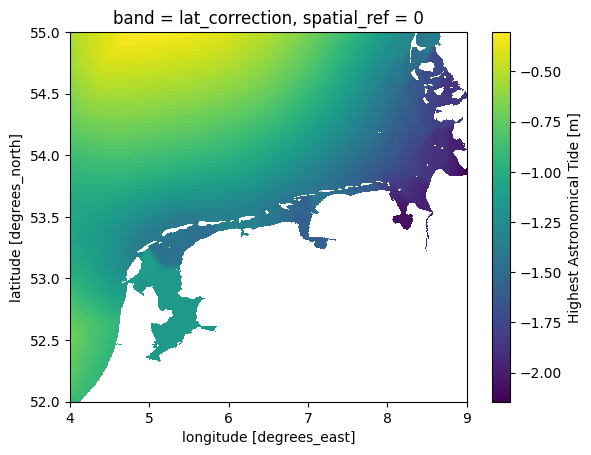

In [8]:
ds_gebco_hat_lat_eu = ds_gebco_hat_lat.rio.clip_box(minx=bounds_europe[0], miny=bounds_europe[1], maxx=bounds_europe[2], maxy=bounds_europe[3], crs=crs)
ds_gebco_hat_lat_eu.isel(band=1).plot.imshow()

### 3. Plot data

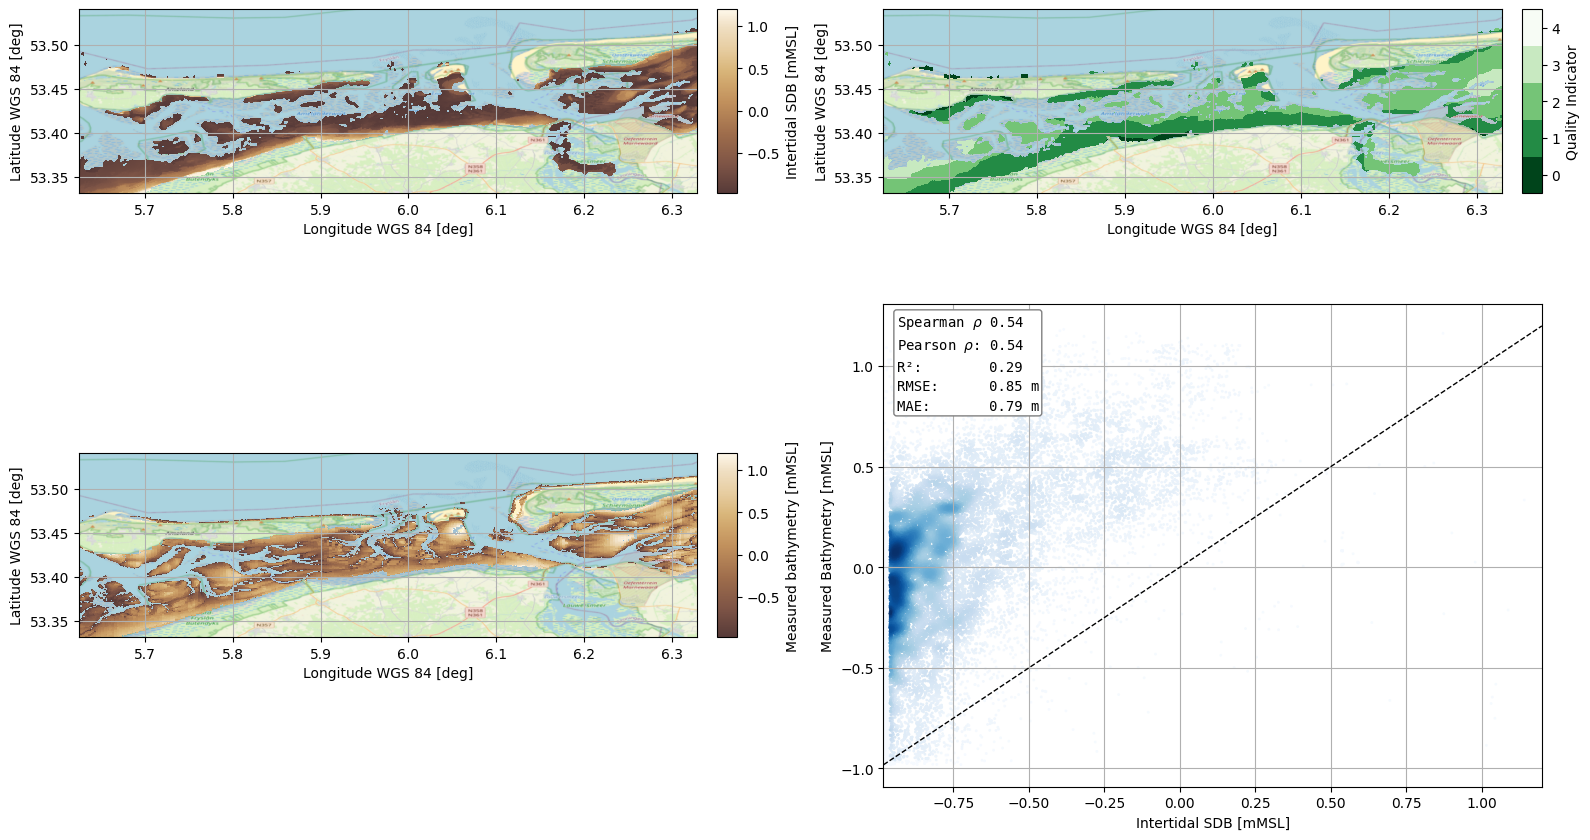

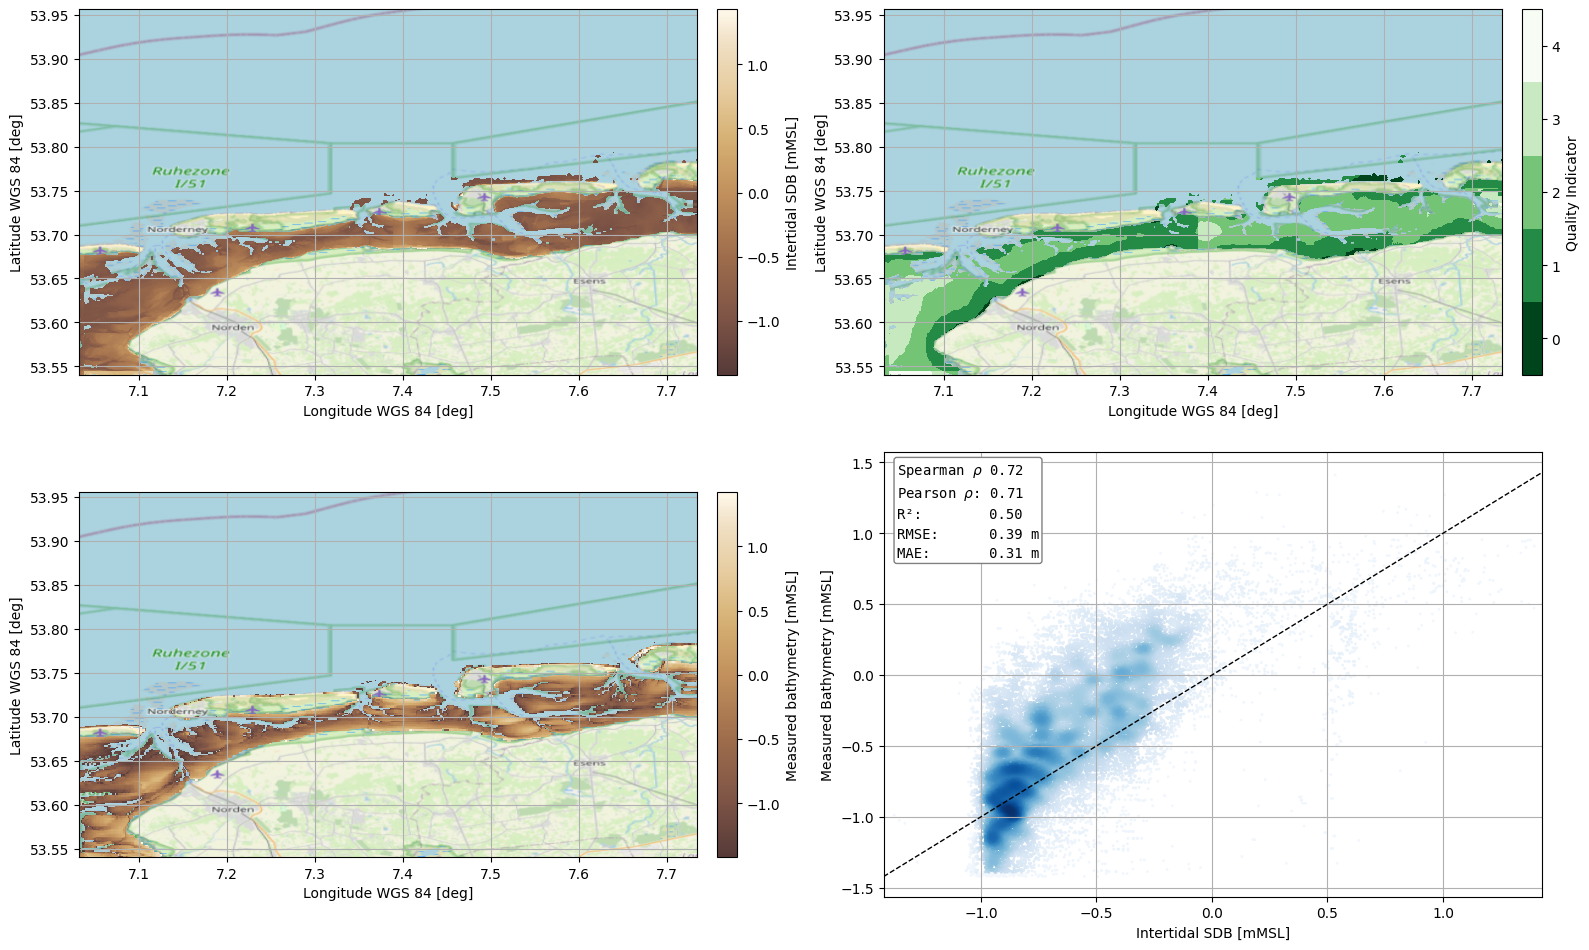

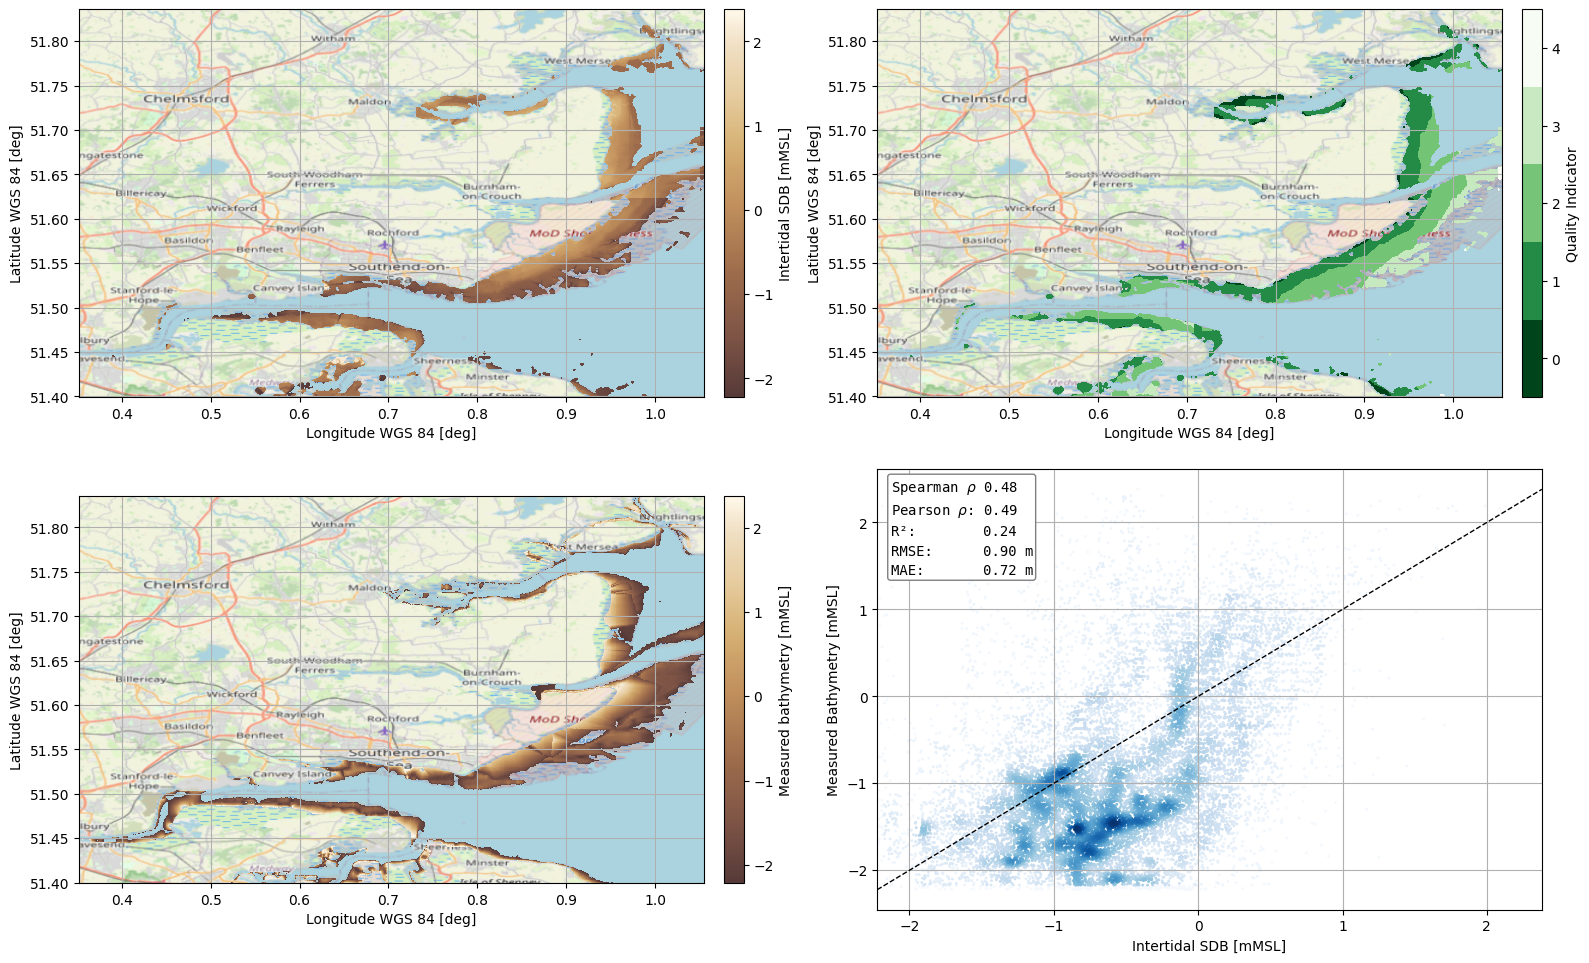

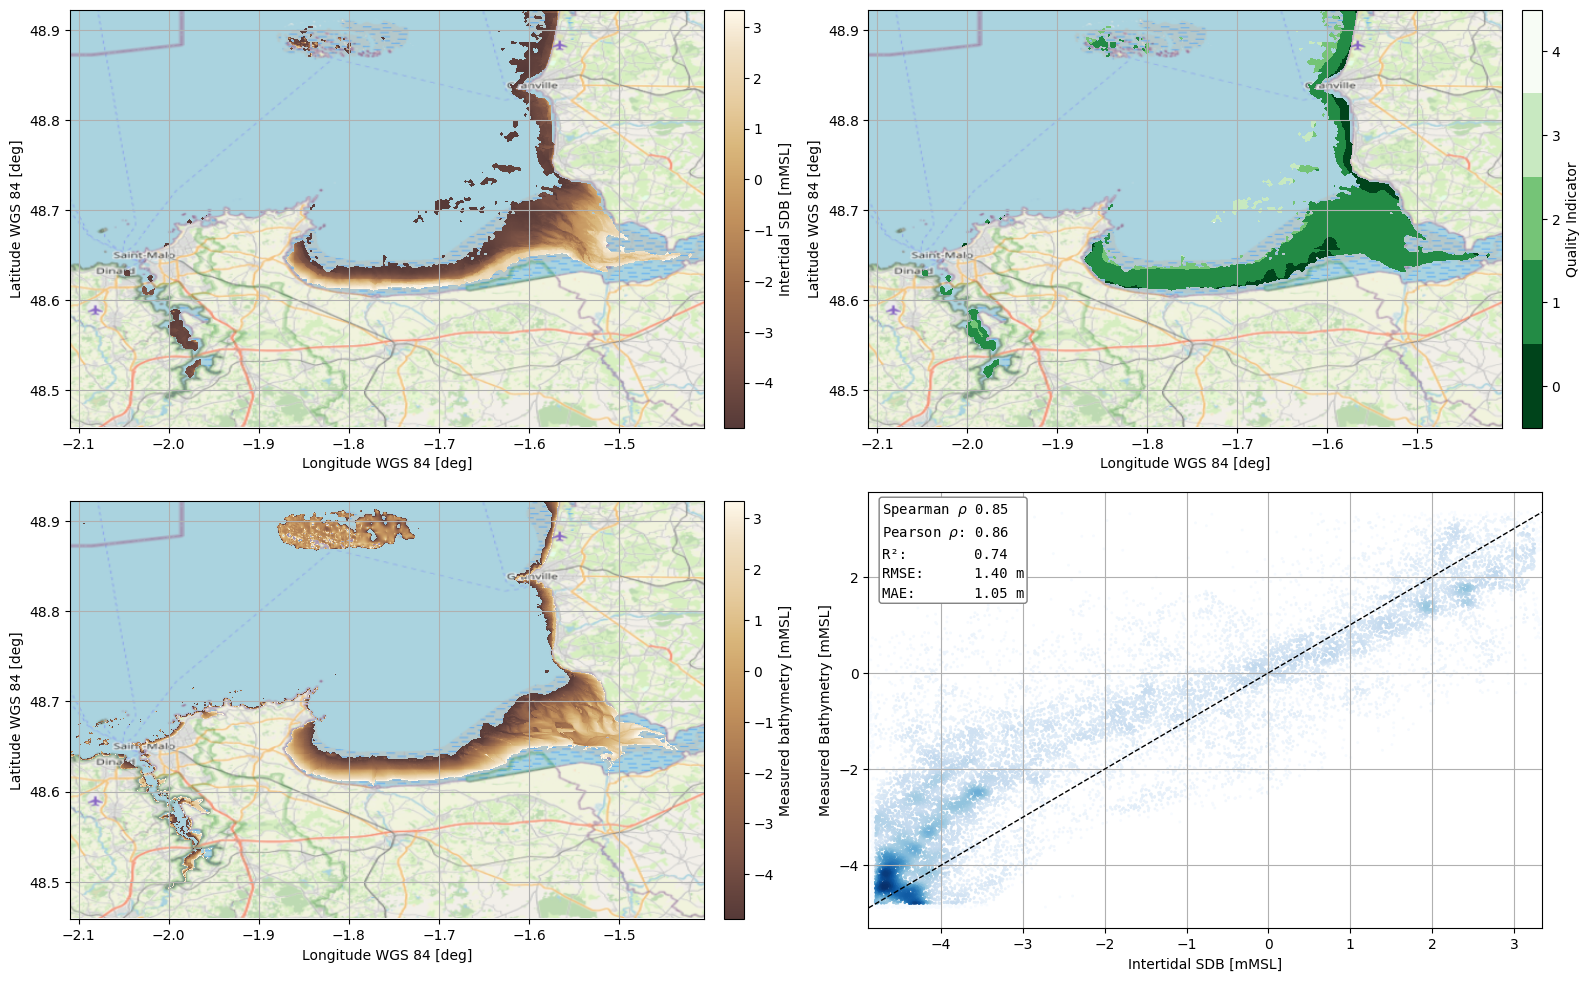

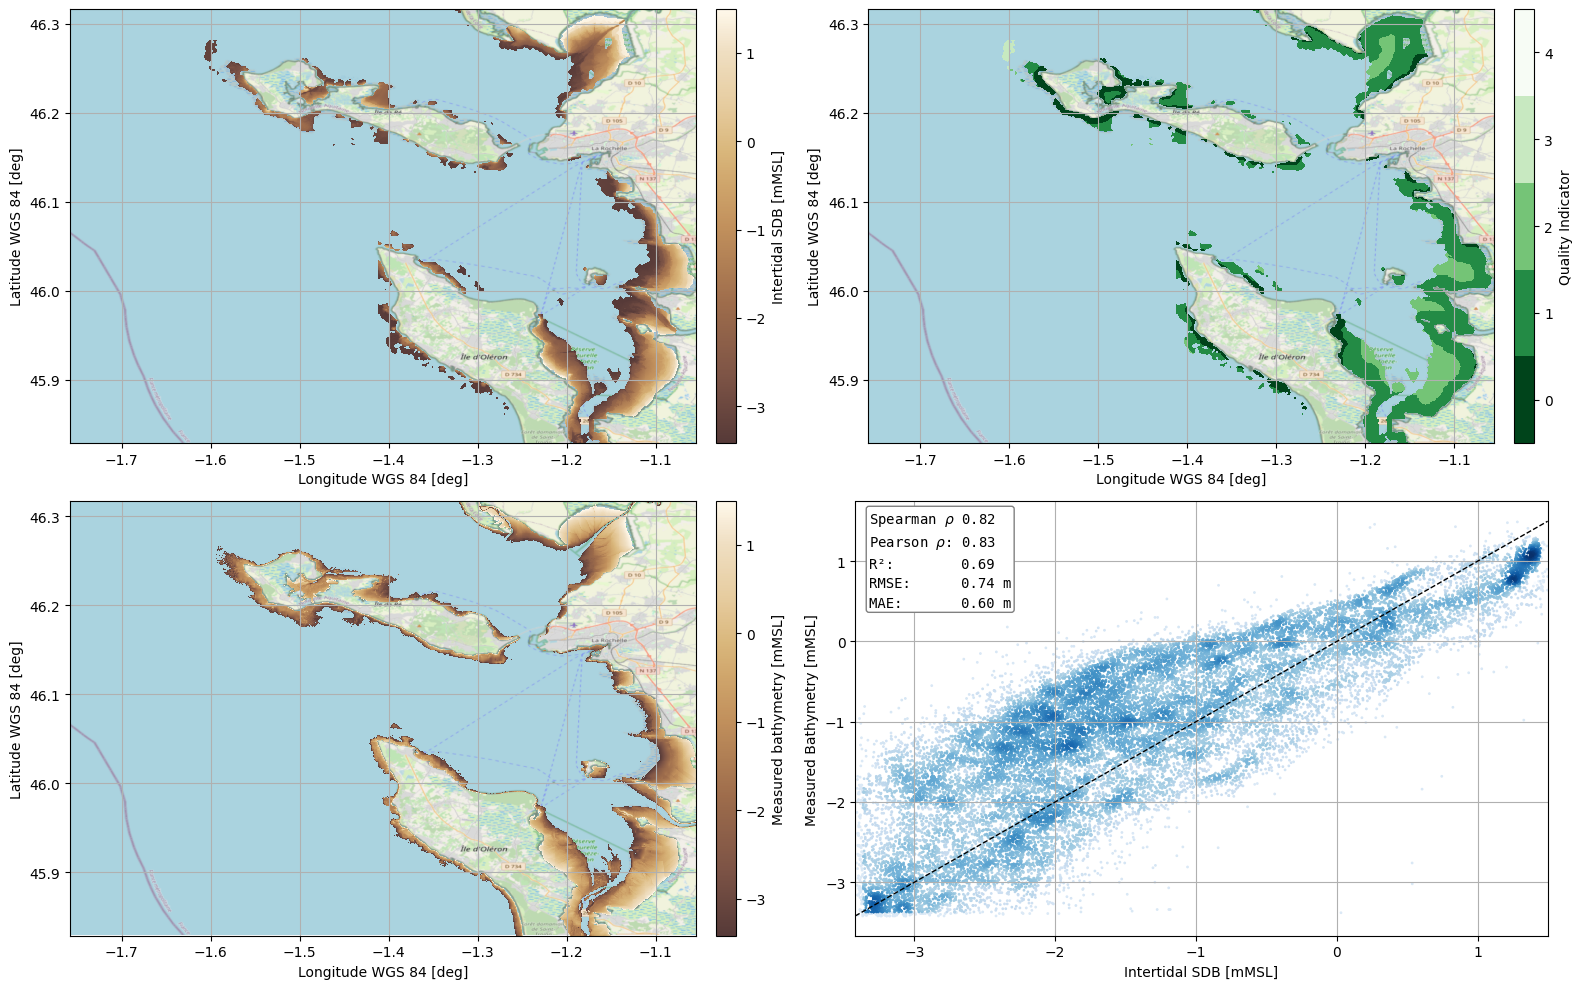

In [9]:
import scipy
def calculate_statistics(x, y):
    # Remove nans
    idx_nans = np.logical_or(np.isnan(x), np.isnan(y))
    x = x[~idx_nans]
    y = y[~idx_nans]

    # Get statistics
    stats = {}
    if len(x) > 2:
        stats['spearman_r'] = scipy.stats.spearmanr(x, y).correlation # Spearman rank-order correlation coefficient (1 = perfect correlation)
        stats['pearson_r'] = scipy.stats.pearsonr(x, y)[0]            # Pearson correlation coefficient (1 = perfect correlation)
        stats['r2'] = scipy.stats.linregress(x, y).rvalue**2          # Coefficient of determination (1 = perfect correlation)
        stats['rmse'] = np.sqrt(np.mean((x - y)**2))            # Root Mean Squared Error (lower is better)
        stats['mae'] = np.mean(np.abs(x - y))                   # Mean Absolute Error (lower is better)
    else:
        stats['spearman_r'] = np.nan
        stats['pearson_r'] = np.nan
        stats['r2'] = np.nan
        stats['rmse'] = np.nan
        stats['mae'] = np.nan

    return stats

from scipy.interpolate import interpn
def density_scatter(x, y, ax, sort = True, bins = 20, **kwargs):
    # Remove nans
    idx_nans = np.logical_or(np.isnan(x), np.isnan(y))
    x = x[~idx_nans]
    y = y[~idx_nans]
    
    data , x_e, y_e = np.histogram2d( x, y, bins = bins, density = True )
    z = interpn( ( 0.5*(x_e[1:] + x_e[:-1]) , 0.5*(y_e[1:]+y_e[:-1]) ) , data , np.vstack([x, y]).T , method = "splinef2d", bounds_error = False)

    #To be sure to plot all data
    z[np.where(np.isnan(z))] = 0.0

    # Sort the points by density, so that the densest points are plotted last
    if sort :
        idx = z.argsort()
        x, y, z = x[idx], y[idx], z[idx]

    # Create a scatter plot
    ax.scatter(x, y, c=z, **kwargs)

    return ax

def plot_statistics(stats, ax):
    text = '\n'.join(['Spearman $\\rho$ {:.2f}'.format(stats['spearman_r']),
                        'Pearson $\\rho$: {:.2f}'.format(stats['pearson_r']),
                        'R²:        {:.2f}'.format(stats['r2']),
                        'RMSE:      {:.2f} m'.format(stats['rmse']),
                        'MAE:       {:.2f} m'.format(stats['mae'])])
    ax.text(0.02, 0.978, text, color='black', transform=ax.transAxes, verticalalignment='top', family='monospace', linespacing=1.5,
            bbox=dict(facecolor='white', edgecolor='grey', boxstyle='round,pad=0.2'))

def plot_data(ds_sdb, ds_insitu, extent_style, vmin=None, vmax=None):
    # Calculate statistics
    x = ds_sdb.isel(band=0).values.flatten()
    y = ds_insitu.values.flatten()
    stats = calculate_statistics(x, y)
    
    # Get vmin and vmax
    if vmin is None:
        vmin = ds_sdb.isel(band=0).min().values
    if vmax is None:
        vmax = ds_sdb.isel(band=0).max().values

    # Create figure and axis
    fig, axs = rpc.subplots(2, 2, figsize=(16, 10))
    axs = axs.flatten()

    # Plot SDB data
    rpc.imshow(ds_sdb.isel(band=0), ax=axs[0], data_style='default', cbar_kwargs={'label': 'Intertidal SDB [mMSL]'}, cmap=cmaps.brown_sable, vmin=vmin, vmax=vmax)

    # Plot SDB quality indicator
    import matplotlib as mpl
    cmap = mpl.colors.ListedColormap(mpl.colormaps['Greens_r'](np.linspace(0, 1, 5)))
    rpc.imshow(ds_sdb.isel(band=1), ax=axs[1], data_style='default', cbar_kwargs={'label': 'Quality Indicator'}, vmin=-0.5, vmax=4.5, cmap=cmap)

    # Plot insitu data
    rpc.imshow(ds_insitu, ax=axs[2], data_style='default', cbar_kwargs={'label': 'Measured bathymetry [mMSL]'}, cmap=cmaps.brown_sable)

    # Plot basemaps
    for ax in axs[0:3]:
        rpc.basemap(crs=crs, ax=ax, map_style='osm', extent_style=extent_style)
    
    # Plot statistics
    x = ds_sdb.isel(band=0).values.flatten()
    y = ds_insitu.values.flatten()
    density_scatter(x, y, axs[3], sort=True, bins=50, cmap='Blues', s=1)
    plot_statistics(stats, axs[3])
    axs[3].plot([vmin, vmax], [vmin, vmax], color='black', linestyle='--', linewidth=1)
    axs[3].set_xlabel('Intertidal SDB [mMSL]')
    axs[3].set_ylabel('Measured Bathymetry [mMSL]')
    axs[3].set_xlim(vmin, vmax)
    axs[3].grid()

    # Show figure
    rpc.show(fig=fig)

plot_data(ds_sdb_dwz, ds_insitu_dwz, extent_style='dutch waddenzee')
plot_data(ds_sdb_gwz, ds_insitu_gwz, extent_style='german waddenzee')
plot_data(ds_sdb_the, ds_insitu_the, extent_style='thames estuary')
plot_data(ds_sdb_msm, ds_insitu_msm, extent_style='le mont-saint-michel')
plot_data(ds_sdb_pda, ds_insitu_pda, extent_style='pertuis d antioche')